<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/Modelling_nonlinear_patterns_with_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is where **non-linear activation functions** come in. They are the key to unlocking your model's ability to learn the complex, curved patterns found in real-world data. In this lab, you'll use the most popular and powerful activation function, **ReLU (Rectified Linear Unit)**, to build a more sophisticated model. By adding a ReLU activation, your model can create multiple "bends" that can approximate the complex delivery time curve.

In this lab, you will:

* Prepare the combined bike and car delivery data, this time applying a technique called **normalization** to help your model train more effectively.
* Build a *non-linear* neural network using the **ReLU** activation function.
* Train your new model to learn the complex, curved relationship in the data.
* Predict delivery times using your new model and see if it can finally succeed where the linear one failed.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import sys
sys.path.append('/content/sample_data/helper_utils.py')

import helper_utils

## Preparing the Non-Linear Data

Start by loading the same dataset that caused problems at the end of the last lab. This is the combined data for both bike and car deliveries.

In [4]:
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

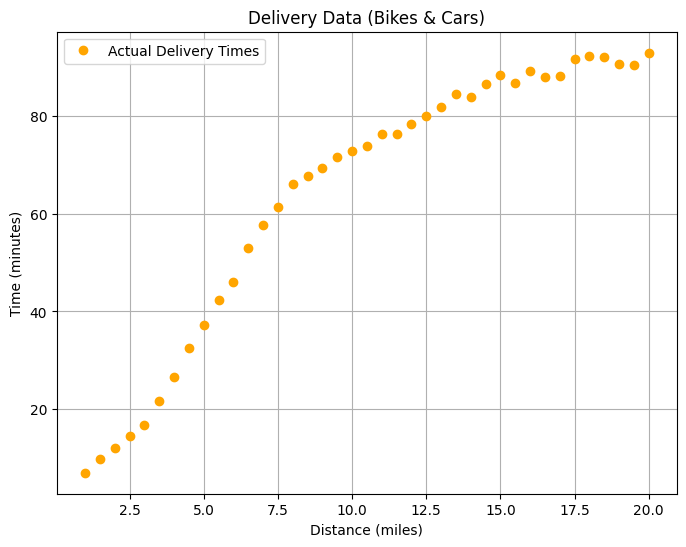

In [5]:
helper_utils.plot_data(distances, times)

### A New Step: Normalizing the Data

Before building your model, you will apply a quick data preparation step called **normalization**. This is a standard technique that makes the training process more stable and effective by adjusting the scale of the data. This adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training. You will explore this topic in greater detail in a later module.

* You will calculate the mean and standard deviation for the `distances` and `times` tensors.
* You will then apply standardization to each tensor using its respective mean and standard deviation, which creates new normalized tensors named `distances_norm` and `times_norm`.
* This specific technique is called **standardization** (or z-score normalization), which converts the original data from `1.0 to 20.0 miles` and approximately `7 to 93 minutes` into a new, normalized scale.

In [9]:
distances_mean = distances.mean()
distances_std = distances.std()

times_mean = times.mean()
times_std = times.std()

distances_norm = (distances - distances_mean) / distances_std

times_norm = (times - times_mean) / times_std

* You will notice the axes now show the data on a new, normalized scale, with distance ranging from approximately `-1.7 to 1.7` and time from `-2.0 to 1.0`.
* Despite this change in scale, the underlying curved pattern of the data remains exactly the same.

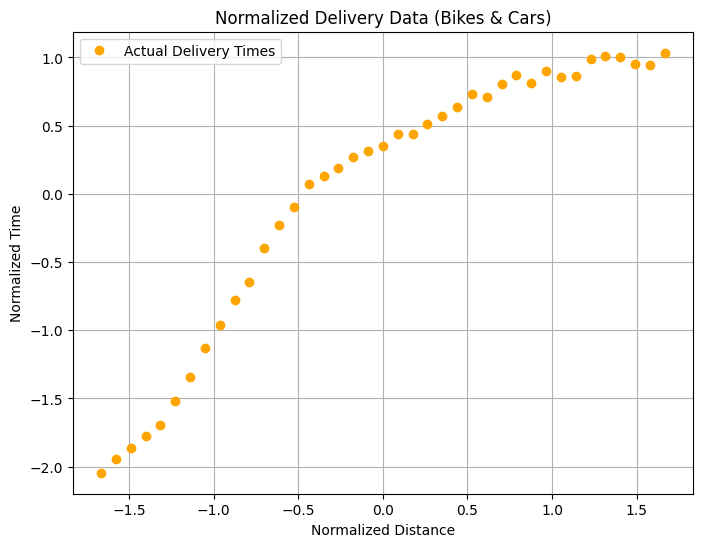

In [10]:
helper_utils.plot_data(distances_norm, times_norm, normalize = True)

## Building the Non-Linear Model

With your normalized data ready, you can now build a model capable of learning its curved pattern. You will define the model's architecture, which now includes a `ReLU` activation function. This structure is what gives your model the ability to learn non-linear relationships.

* `nn.Linear(1, 3)`: This is your **first hidden layer**. It consists of three neurons, each receiving one input feature (the normalized distance). This layer transforms the single input value into three separate values.
* `nn.ReLU()` applies the ReLU activation function to the output of each of the three neurons from the hidden layer. This is the crucial non-linear step that allows your model to create "bends" and learn curves instead of just straight lines.
* `nn.Linear(3, 1)`: This is your **output layer**. It takes the three activated values from the previous step as its input and combines them to produce a single final output, which is your predicted (normalized) delivery time.

This creates a neural network with 1 hidden layer containing 3 neurons.

In [11]:
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3,1)
)

With your model and training tools ready, you can begin the training process.

* You will run the training loop for `3000` epochs (more than Lab 1 because the non-linear pattern is more complex and requires more training). This will repeatedly feed the *normalized* data to your model, measure the error, and adjust the model's parameters to improve its predictions.
* The second half of the code includes a live plot, allowing you to watch in real time as your model's prediction line adapts to fit the curved data. The live plot helps you see how your model gradually learns to fit the curve, starting with a poor fit and improving over time.

**IMPORTANT NOTE**: As the plot updates in real time during training, you might notice a flickering effect. This is the expected behavior of the live visualization and not an issue with your screen.

In [12]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## Checking the Final Fit

Now that training is complete, you will visualize the result.

* You will plot your model's final predicted curve against the original data points.
* This lets you visually inspect how well your non-linear model learned to fit the complex data pattern.

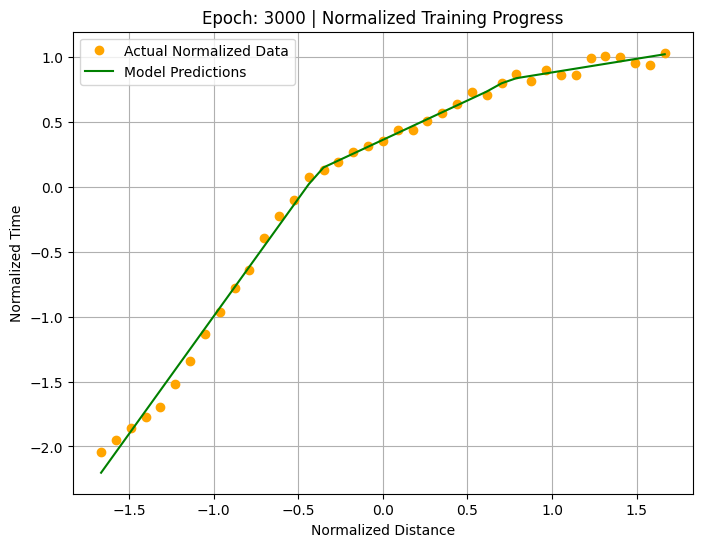

traning complete
final loss: 0.0029688039794564247


In [14]:
for epoch in range(3000):
  optimizer.zero_grad()
  outputs = model(distances_norm)
  loss = loss_function(outputs, times_norm)
  loss.backward()
  optimizer.step()

  if (epoch + 1) % 50 == 0:
      helper_utils.plot_training_progress(
          epoch = epoch,
          loss = loss,
          model = model,
          distances_norm = distances_norm,
          times_norm = times_norm
      )

print("traning complete")
print(f"final loss: {loss.item()}")

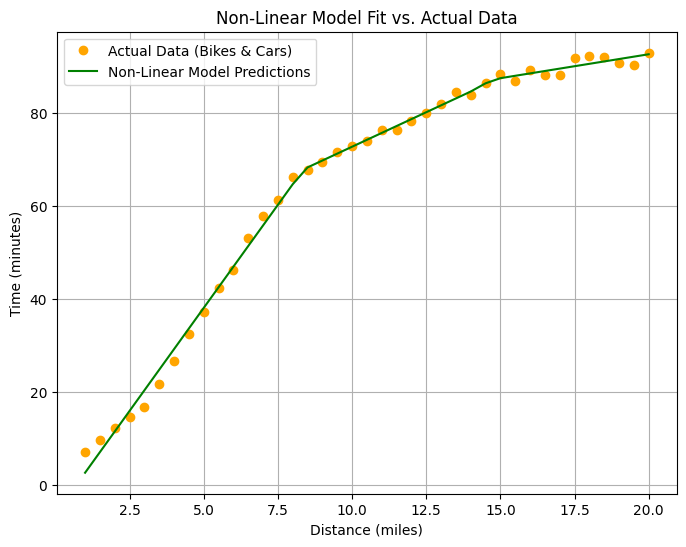

In [15]:
helper_utils.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

In [16]:
distance_to_predict = 5.1

In [17]:
from torch.nn.modules import distance
with torch.no_grad():
  distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
  new_distance_norm = (distance_tensor - distances_mean) / distances_std

  predicted_time_norm = model(new_distance_norm)

  predicted_time_actual = (predicted_time_norm * times_std) + times_mean

  print(f"prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")

  if predicted_time_actual.item() > 45:
    print("decision: do not promise the delivery in under 45 mins")
  else:
      if distance_to_predict <=3:
        print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
      else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")


prediction for a 5.1-mile delivery: 38.9 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.
